In [1]:
%pip install -q plotly scipy seaborn kaleido
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
os.makedirs('images', exist_ok=True)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print(f'NumPy   {np.__version__}')
print(f'Pandas  {pd.__version__}')
print(f'Seaborn {sns.__version__}')
print('[OK] Entorno listo')

Note: you may need to restart the kernel to use updated packages.
NumPy   1.26.4
Pandas  2.2.3
Seaborn 0.13.2
[OK] Entorno listo


# Estadística básica y Análisis Exploratorio de Datos (EDA)

**Objetivo de aprendizaje:** antes de entrenar cualquier modelo predictivo, saber leer lo que
dicen los datos. Este notebook cubre el vocabulario estadístico que aparecerá en todos los
bloques siguientes: variable, distribución, media, varianza, covarianza, correlación
(Pearson y Spearman), y matriz de correlación.

**Advertencia central del bloque:** correlación estadística no implica causalidad. Un modelo
que confunde ambas falla en producción en cuanto cambia la dinámica que creó la coincidencia
histórica.

**Contexto:** los datos de este notebook son sintéticos pero reproducen la
estructura de un ERP real: tickets de soporte, contratos de clientes, frecuencia de login,
incidencias, tiempo de resolución.

---

> **Antes de seguir:** si tuviese acceso a todos los datos históricos de la empresa - tickets,
> logins, contratos, incidencias - , ¿qué variable intentaría predecir primero, y con qué otras
> variables la relacionaría?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

Una respuesta madura menciona: (1) una variable objetivo clara y medible (churn, tiempo de
resolución, unidades vendidas), (2) al menos dos variables de entrada observables antes de
que ocurra el evento, (3) alguna duda sobre si la relación es causal o solo estadística.

Si nadie responde, preguntar: "¿qué sabría del cliente antes de que decida no renovar?"

Señal de comprensión: el alumno distingue entre lo que puede observar hoy y lo que quiere
saber mañana, sin confundir los dos roles.

</details>

---

## 1. Variable: no todo campo es información útil

Una **variable** en estadística es una magnitud que puede tomar distintos valores para
distintas observaciones y cuya variación contiene información. No todo campo de la base de
datos es una variable útil.

| Campo en el ERP | ¿Es variable útil? | Por qué |
|---|---|---|
| ID de ticket | No | Solo identifica; no varía en forma informativa |
| Categoría del ticket | Sí | Su variación predice urgencia y tiempo de resolución |
| Fecha de creación | Depende | Si hay estacionalidad, sí; si los tickets son uniformes, no |
| Texto libre del ticket | Sí (con procesamiento) | Contiene señal pero no en formato numérico directo |

In [2]:
# Dataset la empresa sintetico - 300 clientes
rng = np.random.default_rng(42)
n = 300

meses_contrato  = rng.integers(1, 61, n)
login_freq      = np.clip(rng.normal(15, 5, n), 0, 30).round(1)
num_incidencias = np.clip(rng.normal(5, 3, n), 0, 20).astype(int)
precio_contrato = np.clip(500 + meses_contrato * 60 + rng.normal(0, 300, n), 500, 5000).round(0)
churn_raw       = (0.8 - 0.012 * meses_contrato
                - 0.020 * login_freq
                   + 0.030 * num_incidencias
                   + rng.normal(0, 0.08, n))
churn_prob      = np.clip(churn_raw, 0.05, 0.95).round(3)
ticket_tiempo   = np.clip(rng.exponential(8, n), 1, 96).round(1)

df = pd.DataFrame({
    'id_cliente':       [f'C-{i:04d}' for i in range(n)],
    'meses_contrato':   meses_contrato,
    'login_freq':       login_freq,
    'num_incidencias':  num_incidencias,
    'precio_contrato':  precio_contrato,
    'churn_prob':       churn_prob,
    'ticket_tiempo_h':  ticket_tiempo,
})

print(f'Dataset: {df.shape[0]} clientes, {df.shape[1]} columnas')
print()
print('Resumen estadistico (columnas numericas):')
print(df.drop(columns='id_cliente').describe().round(2))
print()
print('id_cliente: valores unicos =', df['id_cliente'].nunique(),
      '-> identificador, no variable informativa')

Dataset: 300 clientes, 7 columnas

Resumen estadistico (columnas numericas):
       meses_contrato  login_freq  num_incidencias  precio_contrato  \
count          300.00      300.00           300.00           300.00   
mean            30.45       14.98             4.40          2331.70   
std             16.35        4.99             2.89          1032.08   
min              1.00        2.20             0.00           500.00   
25%             17.00       11.50             2.00          1443.50   
50%             30.00       15.05             4.00          2332.00   
75%             44.25       18.20             6.00          3212.00   
max             60.00       29.50            12.00          4451.00   

       churn_prob  ticket_tiempo_h  
count      300.00           300.00  
mean         0.29             8.69  
std          0.20             8.46  
min          0.05             1.00  
25%          0.10             2.58  
50%          0.27             6.00  
75%          0.44       

---

## 2. Distribución: cómo se reparten los valores

La **distribución** de una variable describe qué rango de valores aparece y con qué
frecuencia. El histograma es la visualización más directa para detectar sesgos, bimodalidad
y valores atípicos antes de entrenar cualquier modelo.

Por qué importa antes de entrenar:
- Distribución **sesgada**: algunos algoritmos requieren transformación previa (log, sqrt).
- Distribución **desequilibrada** en el target: el modelo aprende a ignorar la clase
  minoritaria (que suele ser la más importante, ej. fraude, churn).
- **Deriva temporal**: si la distribución cambia entre el período de entrenamiento y
  producción, el modelo predice un mundo que ya no existe.

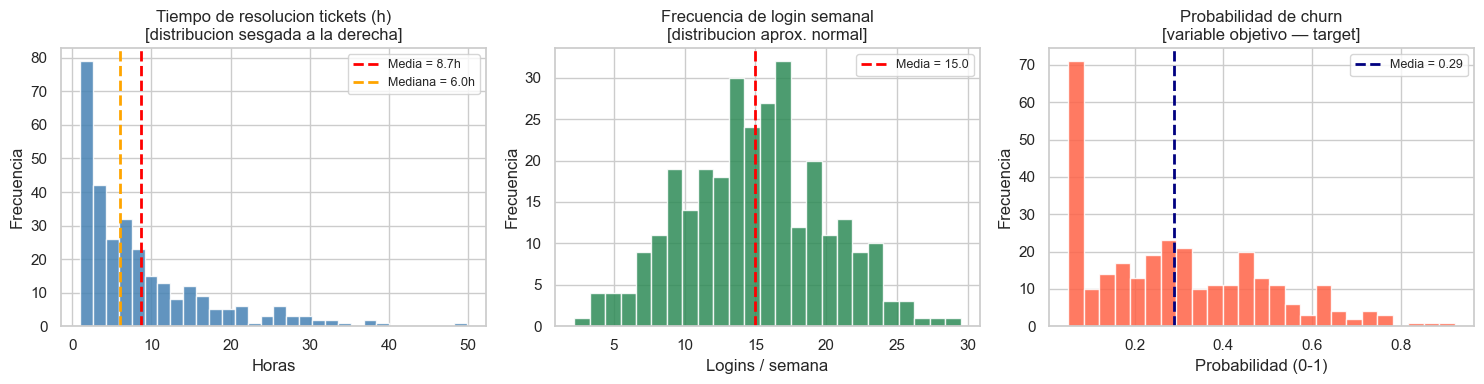

[OK] images/B02A_fig01.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tiempo de resolucion (sesgada a la derecha)
axes[0].hist(df['ticket_tiempo_h'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['ticket_tiempo_h'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Media = {df["ticket_tiempo_h"].mean():.1f}h')
axes[0].axvline(df['ticket_tiempo_h'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana = {df["ticket_tiempo_h"].median():.1f}h')
axes[0].set_title('Tiempo de resolucion tickets (h)\n[distribucion sesgada a la derecha]')
axes[0].set_xlabel('Horas'); axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Login frecuencia (aprox. normal)
axes[1].hist(df['login_freq'], bins=25, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(df['login_freq'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Media = {df["login_freq"].mean():.1f}')
axes[1].set_title('Frecuencia de login semanal\n[distribucion aprox. normal]')
axes[1].set_xlabel('Logins / semana'); axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=9)

# Probabilidad de churn
axes[2].hist(df['churn_prob'], bins=25, color='tomato', edgecolor='white', alpha=0.85)
axes[2].axvline(df['churn_prob'].mean(), color='navy', linestyle='--', linewidth=2,
                label=f'Media = {df["churn_prob"].mean():.2f}')
axes[2].set_title('Probabilidad de churn\n[variable objetivo - target]')
axes[2].set_xlabel('Probabilidad (0-1)'); axes[2].set_ylabel('Frecuencia')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/B02A_fig01.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02A_fig01.png')

**Observaciones:**

- `ticket_tiempo_h`: media (rojo) > mediana (naranja) porque unos pocos tickets muy largos
  arrastran la media hacia arriba. En distribuciones sesgadas, la mediana es más representativa.
- `login_freq`: distribución aproximadamente simétrica. Media ≈ mediana.
- `churn_prob`: distribución del target. Si estuviese muy concentrada cerca de 0 o de 1,
  habría desequilibrio de clases y habría que compensarlo durante el entrenamiento.

---

## 3. Media y varianza: el problema de confiar solo en la media

La **media** responde a "¿cuál es el valor típico?". La **varianza** responde a "¿cuánto se
dispersan los valores alrededor de ese centro?". Dos series con la misma media pueden
tener comportamientos completamente distintos.

In [4]:
# Dos proveedores de la empresa: misma media de entrega, varianza muy distinta
proveedor_A = np.array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4])   # predecible
proveedor_B = np.array([1, 7, 2, 5, 1, 8, 2, 6, 1, 7])   # impredecible

for nombre, datos in [('Proveedor A', proveedor_A), ('Proveedor B', proveedor_B)]:
    print(f'{nombre}: {datos}')
    print(f'  media    = {datos.mean():.2f} dias')
    print(f'  varianza = {datos.var():.2f}')
    print(f'  std      = {datos.std():.2f}')
    print()
print('Misma media. Comportamiento completamente distinto.')

Proveedor A: [3 4 3 4 3 4 3 4 3 4]
  media    = 3.50 dias
  varianza = 0.25
  std      = 0.50

Proveedor B: [1 7 2 5 1 8 2 6 1 7]
  media    = 4.00 dias
  varianza = 7.40
  std      = 2.72

Misma media. Comportamiento completamente distinto.


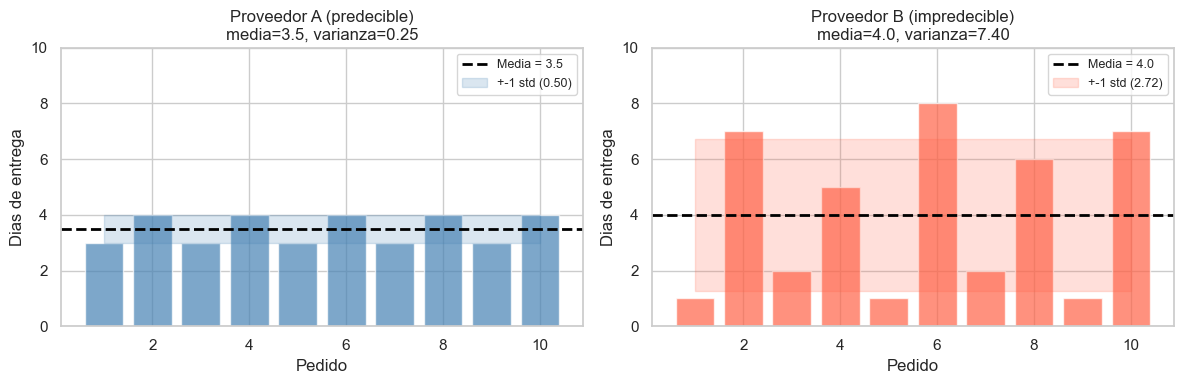

[OK] images/B02A_fig02.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(1, 11)
estilos = [
    (proveedor_A, 'Proveedor A (predecible)', 'steelblue'),
    (proveedor_B, 'Proveedor B (impredecible)', 'tomato'),
]
for ax, (datos, nombre, color) in zip(axes, estilos):
    ax.bar(x, datos, color=color, alpha=0.7, edgecolor='white')
    media = datos.mean()
    std   = datos.std()
    ax.axhline(media, color='black', linestyle='--', linewidth=2,
               label=f'Media = {media:.1f}')
    ax.fill_between(x, media - std, media + std,
                    alpha=0.2, color=color, label=f'+-1 std ({std:.2f})')
    ax.set_title(f'{nombre}\nmedia={media:.1f}, varianza={datos.var():.2f}')
    ax.set_xlabel('Pedido'); ax.set_ylabel('Dias de entrega')
    ax.set_ylim(0, 10); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/B02A_fig02.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02A_fig02.png')

---

## 4. Covarianza y correlación de Pearson: cómo se mueven dos variables juntas

La **covarianza** mide si dos variables tienden a moverse en la misma dirección (positiva)
o en sentidos opuestos (negativa). La **correlación de Pearson** normaliza esa medida a
[-1, +1] para compararla independientemente de las unidades.

```
r = covarianza(X, Y) / (std(X) * std(Y))

  r = +1.0  ->  relación lineal perfecta positiva
  r = +0.7  ->  relación positiva moderada-alta
  r =  0.0  ->  sin relación lineal detectable
  r = -0.7  ->  relación negativa moderada-alta
  r = -1.0  ->  relación lineal perfecta negativa
```

**Limitación:** Pearson solo captura relaciones **lineales**. Para relaciones monótonas
no lineales, usar Spearman (sección 5).

In [6]:
# Calculo manual de covarianza y Pearson - paso a paso
X = df['num_incidencias'].values.astype(float)
Y = df['churn_prob'].values

# Paso 1: medias
media_X = X.mean()
media_Y = Y.mean()

# Paso 2: desviaciones respecto a la media
dX = X - media_X
dY = Y - media_Y

# Paso 3: covarianza
covarianza = (dX * dY).mean()

# Paso 4: desviaciones estandar
std_X = X.std()
std_Y = Y.std()

# Paso 5: correlacion de Pearson
r_manual = covarianza / (std_X * std_Y)

# Verificacion
r_scipy, p_val = stats.pearsonr(X, Y)

print(f'Covarianza(incidencias, churn_prob) = {covarianza:.4f}')
print(f'Correlacion Pearson  (manual)       = {r_manual:.4f}')
print(f'Correlacion Pearson  (scipy)        = {r_scipy:.4f}  [verificacion OK]')
print(f'p-valor                             = {p_val:.2e}')
print()
umbral = abs(r_scipy)
if umbral > 0.5:
    print('[!] Correlacion moderada-alta -> candidato solido a feature')
elif umbral > 0.2:
    print('[!] Correlacion debil -> puede aportar como feature secundario')
else:
    print('[!] Correlacion muy debil -> investigar relacion no lineal antes de descartar')

Covarianza(incidencias, churn_prob) = 0.1672
Correlacion Pearson  (manual)       = 0.2871
Correlacion Pearson  (scipy)        = 0.2871  [verificacion OK]
p-valor                             = 4.20e-07

[!] Correlacion debil -> puede aportar como feature secundario


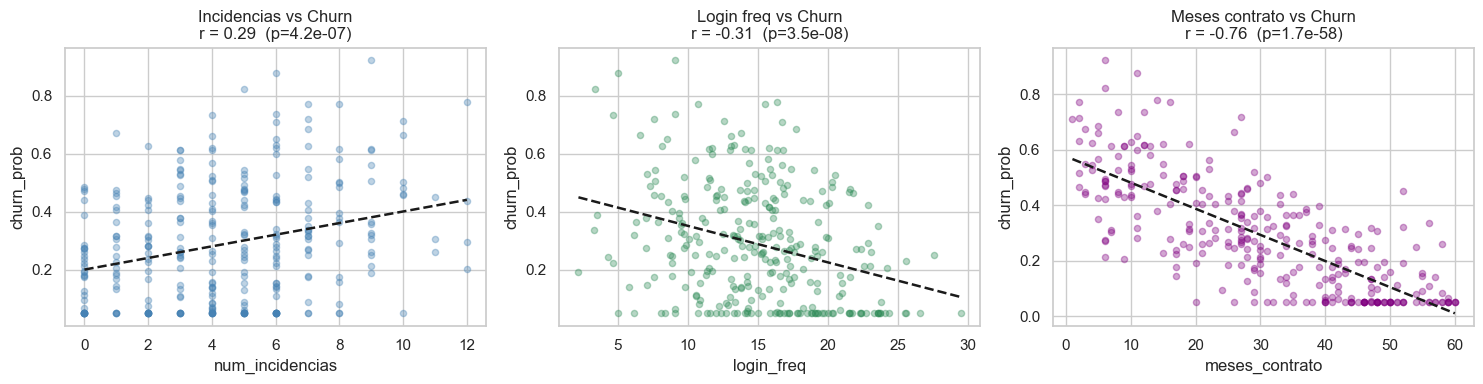

[OK] images/B02A_fig03.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pares = [
    ('num_incidencias', 'churn_prob', 'Incidencias vs Churn',    'steelblue'),
    ('login_freq',      'churn_prob', 'Login freq vs Churn',     'seagreen'),
    ('meses_contrato',  'churn_prob', 'Meses contrato vs Churn', 'purple'),
]

for ax, (col_x, col_y, titulo, color) in zip(axes, pares):
    r, p = stats.pearsonr(df[col_x], df[col_y])
    ax.scatter(df[col_x], df[col_y], alpha=0.35, color=color, s=20)
    m, b = np.polyfit(df[col_x], df[col_y], 1)
    xline = np.linspace(df[col_x].min(), df[col_x].max(), 100)
    ax.plot(xline, m * xline + b, 'k--', linewidth=1.8)
    ax.set_title(f'{titulo}\nr = {r:.2f}  (p={p:.1e})')
    ax.set_xlabel(col_x); ax.set_ylabel(col_y)

plt.tight_layout()
plt.savefig('images/B02A_fig03.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02A_fig03.png')

---

## 5. Correlación de Spearman: cuando la relación no es lineal

Spearman opera sobre los **rangos** (posiciones ordenadas) de los valores, no sobre los
valores directos. Detecta cualquier relación monótona (siempre crece o siempre decrece),
aunque no sea lineal.

```
Tipo de relación          Pearson detecta?   Spearman detecta?
─────────────────────────────────────────────────────────────
Lineal perfecta           Si (r = 1.0)       Si (r = 1.0)
Lineal con ruido          Si (r alto)        Si (r similar)
Monótona no lineal        Parcial            Si (r alto)
No monótona (en U)        No (r ~ 0)         No (r ~ 0)
Variables ordinales       No aplicable       Si
```

**Regla práctica:** calcular siempre ambas. Si Pearson y Spearman difieren
significativamente, la relación es probablemente no lineal.

In [8]:
rng_sp = np.random.default_rng(7)
x_v = np.linspace(0.5, 10, 80)
y_lineal   = 2 * x_v + rng_sp.normal(0, 1, 80)
y_cuadrat  = x_v**2  + rng_sp.normal(0, 3, 80)
y_en_u     = -(x_v - 5)**2 + rng_sp.normal(0, 2, 80)

resultados = []
for nombre, y in [('Lineal', y_lineal), ('Cuadratica (monotona)', y_cuadrat), ('En U (no monotona)', y_en_u)]:
    rp, _ = stats.pearsonr(x_v, y)
    rs, _ = stats.spearmanr(x_v, y)
    resultados.append({'Relacion': nombre, 'Pearson r': round(rp, 3), 'Spearman r': round(rs, 3)})

print(pd.DataFrame(resultados).to_string(index=False))
print()
print('Observacion: cuadratica -> Spearman detecta la monotonia que Pearson subestima.')
print('  En U: ambas fallen porque la relacion no es monotona.')

             Relacion  Pearson r  Spearman r
               Lineal      0.989       0.989
Cuadratica (monotona)      0.969       0.992
   En U (no monotona)     -0.197      -0.160

Observacion: cuadratica -> Spearman detecta la monotonia que Pearson subestima.
  En U: ambas fallen porque la relacion no es monotona.


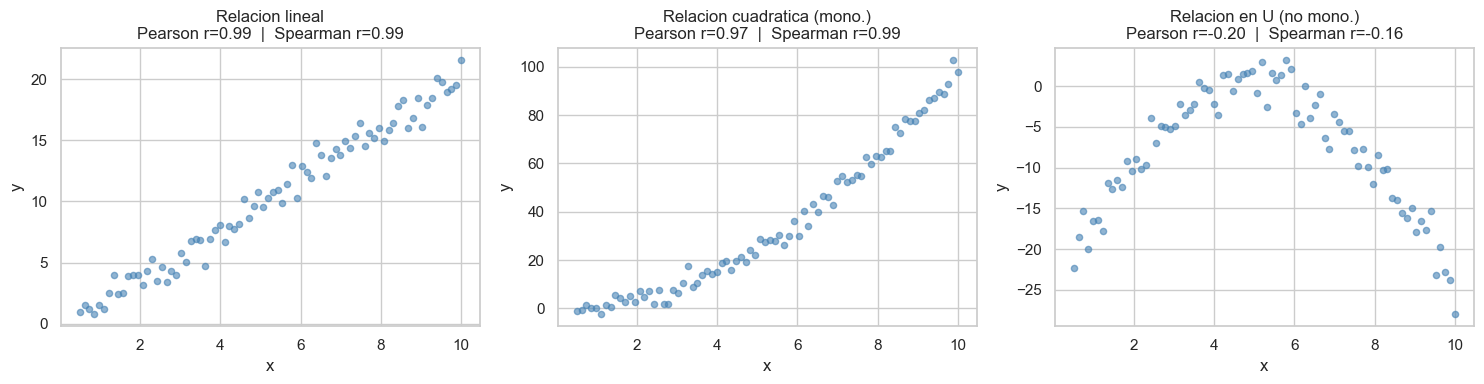

[OK] images/B02A_fig04.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, y) in zip(axes, [
    ('Relacion lineal',              y_lineal),
    ('Relacion cuadratica (mono.)',  y_cuadrat),
    ('Relacion en U (no mono.)',     y_en_u),
]):
    rp, _ = stats.pearsonr(x_v, y)
    rs, _ = stats.spearmanr(x_v, y)
    ax.scatter(x_v, y, alpha=0.6, s=20, color='steelblue')
    ax.set_title(f'{nombre}\nPearson r={rp:.2f}  |  Spearman r={rs:.2f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.savefig('images/B02A_fig04.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02A_fig04.png')

---

## 6. Matriz de correlación y heatmap

Con múltiples variables, se organiza la correlación entre cada par en una **matriz de
correlación**. El **heatmap** la visualiza con escala de color. La diagonal siempre es 1.
La matriz es simétrica.

Lo que se busca:
- **Variables correlacionadas con el target** (candidatos a feature).
- **Variables muy correlacionadas entre sí** (multicolinealidad - información redundante).
- **Variables sin correlación con nada** (posible ruido - candidatas a eliminar).

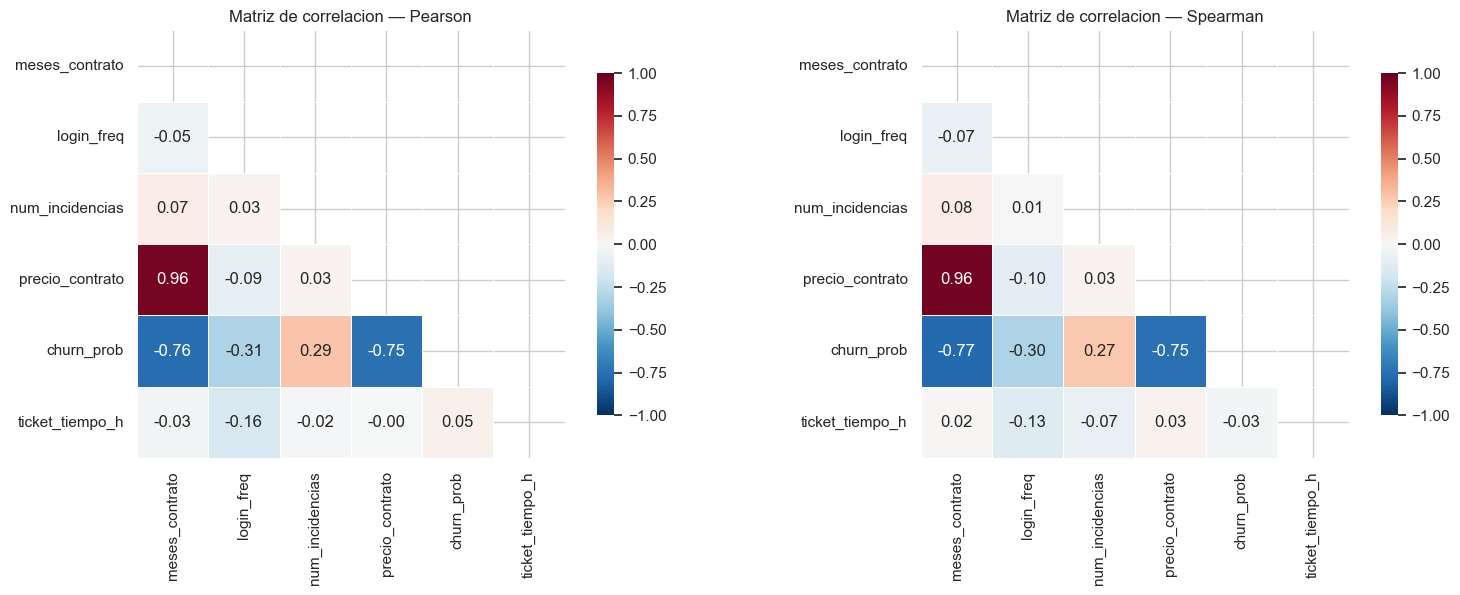

[OK] images/B02A_fig05.png

Variables mas correlacionadas con churn_prob (Pearson):
meses_contrato    -0.763
precio_contrato   -0.746
login_freq        -0.312
num_incidencias    0.287
ticket_tiempo_h    0.047
Name: churn_prob, dtype: float64


In [10]:
cols_num = ['meses_contrato', 'login_freq', 'num_incidencias',
            'precio_contrato', 'churn_prob', 'ticket_tiempo_h']

corr_p = df[cols_num].corr(method='pearson')
corr_s = df[cols_num].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, corr, titulo in [(axes[0], corr_p, 'Pearson'), (axes[1], corr_s, 'Spearman')]:
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', vmin=-1, vmax=1, center=0,
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'Matriz de correlacion - {titulo}', fontsize=12)

plt.tight_layout()
plt.savefig('images/B02A_fig05.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02A_fig05.png')
print()
print('Variables mas correlacionadas con churn_prob (Pearson):')
print(corr_p['churn_prob'].drop('churn_prob').sort_values(key=abs, ascending=False).round(3))

---

## 7. Exploración interactiva

El scatter interactivo permite explorar relaciones entre variables y detectar grupos,
tendencias y outliers antes de entrenar. Pasa el cursor sobre los puntos para ver los
detalles de cada cliente.

In [11]:
df_plot = df.copy()
df_plot['riesgo'] = pd.cut(df['churn_prob'],
                            bins=[0, 0.33, 0.66, 1.0],
                            labels=['bajo', 'medio', 'alto'])

fig_px = px.scatter(
    df_plot,
    x='num_incidencias',
    y='login_freq',
    color='churn_prob',
    size='precio_contrato',
    hover_data=['meses_contrato', 'ticket_tiempo_h', 'riesgo'],
    color_continuous_scale='RdBu_r',
    title='Clientes la empresa - Incidencias vs Login (color=churn, tamaño=precio)',
    labels={
        'num_incidencias': 'Num. incidencias / mes',
        'login_freq':      'Logins / semana',
        'churn_prob':      'Riesgo churn',
        'precio_contrato': 'Precio (EUR)',
    }
)
fig_px.update_layout(height=500)
fig_px.show()

# Guardar
try:
    fig_px.write_image('images/B02A_fig06.png', scale=2)
    print('[OK] images/B02A_fig06.png')
except Exception:
    fig_px.write_html('images/B02A_fig06.html')
    print('[OK] images/B02A_fig06.html  (kaleido no disponible - guardado como HTML)')

[OK] images/B02A_fig06.html  (kaleido no disponible -  guardado como HTML)


In [12]:
# Tabla comparativa: correlacion con churn_prob por metodo
tabla = pd.DataFrame({
    'Variable': [c for c in cols_num if c != 'churn_prob'],
    'Pearson r': [round(corr_p.loc[c, 'churn_prob'], 3) for c in cols_num if c != 'churn_prob'],
    'Spearman r': [round(corr_s.loc[c, 'churn_prob'], 3) for c in cols_num if c != 'churn_prob'],
})
tabla['|Pearson|'] = tabla['Pearson r'].abs()
tabla = tabla.sort_values('|Pearson|', ascending=False).drop(columns='|Pearson|')

print('Correlacion con churn_prob (target) - Pearson vs Spearman:')
print()
print(tabla.to_string(index=False))
print()
print('Regla rapida:')
print('  |r| > 0.5   -> candidato solido a feature')
print('  |r| 0.2-0.5 -> feature secundario; investigar relacion no lineal')
print('  |r| < 0.2   -> poca correlacion lineal; evaluar con Spearman o descartar')

Correlacion con churn_prob (target) -  Pearson vs Spearman:

       Variable  Pearson r  Spearman r
 meses_contrato     -0.763      -0.774
precio_contrato     -0.746      -0.753
     login_freq     -0.312      -0.305
num_incidencias      0.287       0.266
ticket_tiempo_h      0.047      -0.028

Regla rapida:
  |r| > 0.5   -> candidato solido a feature
  |r| 0.2-0.5 -> feature secundario; investigar relacion no lineal
  |r| < 0.2   -> poca correlacion lineal; evaluar con Spearman o descartar


---

## 8. [ADVERTENCIA] Correlación no implica causalidad

**Correlación mide asociación estadística, no mecanismo causal.**

Que dos variables varíen juntas en el histórico no significa que una cause la otra.
Puede haber una tercera variable que cause ambas (**variable confusora**), una coincidencia
temporal, o una relación que existió en el pasado pero no se repetirá.

Un modelo aprende cualquier correlación presente en los datos, causal o no. Si esa
correlación desaparece en producción, el modelo falla de formas difíciles de diagnosticar.

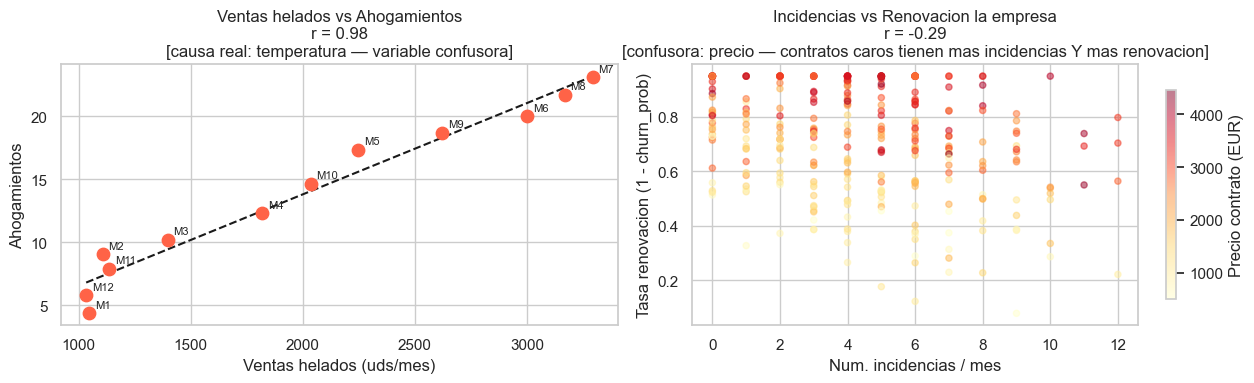

[OK] images/B02A_fig07.png

CRITERIO OPERATIVO:
  Para cada variable con |r| > 0.4 con el target, preguntar:
  "Existe un mecanismo de negocio que explique POR QUE esta variable
   anticipa el target, independientemente del historico?"
  Si la respuesta es "no se", investigar antes de incluirla en el modelo.


In [13]:
rng_e = np.random.default_rng(17)
meses_e       = np.arange(1, 13)
temperatura   = np.array([8, 9, 12, 16, 20, 25, 28, 27, 22, 17, 11, 8])
ventas_helado = temperatura * 120 + rng_e.normal(0, 80, 12)
ahogamientos  = temperatura * 0.8 + rng_e.normal(0, 1.0, 12)

r_esp, _ = stats.pearsonr(ventas_helado, ahogamientos)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: correlacion espuria clasica
axes[0].scatter(ventas_helado, ahogamientos, color='tomato', s=80, zorder=3)
for i, m in enumerate(meses_e):
    axes[0].annotate(f'M{m}', (ventas_helado[i], ahogamientos[i]),
                     textcoords='offset points', xytext=(4, 4), fontsize=8)
m_fit, b_fit = np.polyfit(ventas_helado, ahogamientos, 1)
xl = np.linspace(ventas_helado.min(), ventas_helado.max(), 100)
axes[0].plot(xl, m_fit * xl + b_fit, 'k--', linewidth=1.5)
axes[0].set_title(f'Ventas helados vs Ahogamientos\nr = {r_esp:.2f}\n[causa real: temperatura - variable confusora]')
axes[0].set_xlabel('Ventas helados (uds/mes)'); axes[0].set_ylabel('Ahogamientos')

# Panel 2: correlacion espuria en la empresa
r_spr, _ = stats.pearsonr(df['num_incidencias'], 1 - df['churn_prob'])
sc = axes[1].scatter(df['num_incidencias'], 1 - df['churn_prob'],
                     c=df['precio_contrato'], cmap='YlOrRd', alpha=0.5, s=20)
axes[1].set_title(f'Incidencias vs Renovacion la empresa\nr = {r_spr:.2f}\n[confusora: precio - contratos caros tienen mas incidencias Y mas renovacion]')
axes[1].set_xlabel('Num. incidencias / mes')
axes[1].set_ylabel('Tasa renovacion (1 - churn_prob)')
plt.colorbar(sc, ax=axes[1], label='Precio contrato (EUR)', shrink=0.8)

plt.tight_layout()
plt.savefig('images/B02A_fig07.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02A_fig07.png')
print()
print('CRITERIO OPERATIVO:')
print('  Para cada variable con |r| > 0.4 con el target, preguntar:')
print('  "Existe un mecanismo de negocio que explique POR QUE esta variable')
print('   anticipa el target, independientemente del historico?"')
print('  Si la respuesta es "no se", investigar antes de incluirla en el modelo.')

---

## Ejercicio técnico

**Enunciado:** se dispone de un dataset con métricas de tickets de soporte de la empresa.
Calcular la correlación de Pearson y Spearman entre cada feature y el tiempo de resolución
(`tiempo_h`), e identificar las dos variables más predictivas.

**Features disponibles:**
- `prioridad_num`: prioridad del ticket (1=baja, 2=media, 3=alta)
- `modulo_id`: módulo del ERP relacionado (1-8)
- `cliente_senior`: cliente con más de 24 meses (0/1)
- `hora_apertura`: hora de apertura del ticket (0-23)

In [14]:
# Datos del ejercicio (ya preparados)
rng2 = np.random.default_rng(99)
n_t = 200
prioridad = rng2.integers(1, 4, n_t)
senior    = rng2.integers(0, 2, n_t)

tickets_df = pd.DataFrame({
    'prioridad_num':  prioridad,
    'modulo_id':      rng2.integers(1, 9, n_t),
    'cliente_senior': senior,
    'hora_apertura':  rng2.integers(0, 24, n_t),
    'tiempo_h': np.clip(
        12 - 3 * prioridad + rng2.normal(0, 3, n_t) + 4 * senior,
        1, 48
    ).round(1),
})

print('tickets_df shape:', tickets_df.shape)
print()
tickets_df.head()

tickets_df shape: (200, 5)



,prioridad_num,modulo_id,cliente_senior,hora_apertura,tiempo_h
0,3,7,1,5,10.1
1,2,4,0,5,7.5
2,3,2,1,4,10.0
3,2,5,1,18,7.3
4,1,1,0,17,9.3


In [15]:
# TODO: completar el calculo
features = [c for c in tickets_df.columns if c != 'tiempo_h']

# Paso 1: calcular Pearson y Spearman para cada feature con tiempo_h
# resultados = []
# for col in features:
#     r_p, p_p = stats.pearsonr(tickets_df[col], tickets_df['tiempo_h'])
#     r_s, p_s = stats.spearmanr(tickets_df[col], tickets_df['tiempo_h'])
#     resultados.append({'Feature': col, 'Pearson r': ..., 'Spearman r': ...})

# Paso 2: ordenar por |Pearson r| descendente
# ...

# PISTA: esperar prioridad_num y cliente_senior como las mas correlacionadas
print('Completa el codigo y vuelve a ejecutar esta celda.')

Completa el codigo y vuelve a ejecutar esta celda.


In [16]:
# SOLUCION COMENTADA - ejecutar solo tras intentar el ejercicio
features = [c for c in tickets_df.columns if c != 'tiempo_h']
resultados = []

for col in features:
    rp, pp = stats.pearsonr(tickets_df[col], tickets_df['tiempo_h'])
    rs, _  = stats.spearmanr(tickets_df[col], tickets_df['tiempo_h'])
    resultados.append({
        'Feature': col,
        'Pearson r': round(rp, 3),
        'p-valor': round(pp, 4),
        'Spearman r': round(rs, 3),
    })

res_df = pd.DataFrame(resultados).sort_values('Pearson r', key=abs, ascending=False)

print('Correlacion de features con tiempo_h:')
print()
print(res_df.to_string(index=False))
print()
top2 = res_df['Feature'].head(2).tolist()
print(f'Las dos variables mas predictivas: {top2}')
print()
print('Interpretacion:')
print('  prioridad_num (negativa): mayor prioridad -> menor tiempo de resolucion')
print('  cliente_senior (positiva): clientes senior -> tickets mas complejos -> mas tiempo')
print('  Verificar con negocio si ambas relaciones tienen mecanismo causal plausible.')

Correlacion de features con tiempo_h:

       Feature  Pearson r  p-valor  Spearman r
cliente_senior      0.529   0.0000       0.530
 prioridad_num     -0.487   0.0000      -0.477
     modulo_id      0.063   0.3781       0.063
 hora_apertura     -0.028   0.6893      -0.029

Las dos variables mas predictivas: ['cliente_senior', 'prioridad_num']

Interpretacion:
  prioridad_num (negativa): mayor prioridad -> menor tiempo de resolucion
  cliente_senior (positiva): clientes senior -> tickets mas complejos -> mas tiempo
  Verificar con negocio si ambas relaciones tienen mecanismo causal plausible.


---

## Ejercicio de decisión (sin código)

**Caso:** el equipo de análisis de la empresa detecta correlación r = 0.71 entre
"número de llamadas al departamento de ventas en los últimos 6 meses" y
"renovación del contrato en el trimestre siguiente".

El responsable de Customer Success propone entrenar un modelo que marque como riesgo de
churn a los clientes que no han llamado a ventas en 6 meses, y active una campaña proactiva.

---

**Preguntas:**

1. ¿Usarías un modelo de ML aquí, o sería suficiente una regla determinista?
2. Antes de entrenar, ¿qué pregunta harías sobre esta correlación?
3. ¿Qué variable confusora podría explicar la correlación sin que las llamadas causen la renovación?
4. ¿Qué criterio operativo aplicarías para decidir si incluir esta variable como feature?

**Espacio para argumentar:**

> [escribe tu razonamiento aquí]

---

<details>
<summary>Criterios de evaluación (desplegar tras el ejercicio)</summary>

**Respuesta madura incluye:**

1. Reconocer que r = 0.71 es alta pero no prueba causal. Una regla determinista puede
   funcionar, pero un modelo captura mejor combinaciones de señales. Ambas son válidas;
   la elección depende de cuántas variables se quieren combinar.

2. La pregunta clave: "¿por qué los clientes que llaman más renuevan más? ¿Llaman porque
   están satisfechos, o porque tienen problemas que ventas resuelve activamente?"

3. Variable confusora probable: tamaño o complejidad del contrato. Los clientes grandes
   llaman más a ventas (necesitan más gestión comercial) Y renuevan más (por inercia
   contractual), independientemente de las llamadas.

4. Criterio operativo: diseñar un experimento A/B donde algunos clientes sin llamadas
   reciben contacto proactivo y otros no, para verificar si el contacto causa renovación
   o solo existe correlación espuria.

**Señal de comprensión:** el alumno no descarta el modelo, pero propone validación causal
antes de actuar sobre la correlación como si fuera mecanismo.

</details>

---

## Normalización y escalado de variables

Antes de usar variables numéricas en un modelo, hay que asegurarse de que
sus escalas son comparables. Si una variable mide miles y otra mide unidades,
los algoritmos basados en distancias o gradientes tratarán la primera como
más importante solo por su magnitud.

Este paso forma parte del EDA porque **el rango y la distribución de cada
variable determinan si es necesario escalar** antes de entrenar.

In [17]:
# Cargamos el CSV de métricas de uso (creado en B02D)
import pathlib, numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

IMG = pathlib.Path('images')
IMG.mkdir(exist_ok=True)

csv_path = pathlib.Path('data/metricas_uso_erp.csv')
if csv_path.exists():
    df_erp = pd.read_csv(csv_path)
else:
    # Fallback: generar datos mínimos para la demo
    np.random.seed(42)
    n = 200
    df_erp = pd.DataFrame({
        'volumen_transacciones': np.random.uniform(50, 5000, n),
        'modulos_activos':       np.random.randint(1, 11, n),
        'login_frecuencia':      np.random.uniform(1, 35, n),
        'nps':                   np.random.randint(-100, 101, n),
    })

DEMO_COLS = ['volumen_transacciones', 'modulos_activos',
             'login_frecuencia', 'nps']
df_demo = df_erp[DEMO_COLS].copy()

print("Rangos ANTES de normalizar:")
print(df_demo.describe().loc[['min','max','mean','std']].round(2).to_string())

Rangos ANTES de normalizar:
      volumen_transacciones  modulos_activos  login_frecuencia    nps
min                   10.00             1.00              1.00 -61.00
max                  553.00             9.00             31.30  85.00
mean                 249.75             4.13             15.42  17.07
std                  120.67             2.00              6.99  31.56


### El problema de escala

Con rangos tan distintos, un algoritmo de distancia (KNN) o de gradiente
(Regresión Lineal) trata `volumen_transacciones` como 500× más importante
que `modulos_activos` - no porque lo sea, sino por la magnitud de sus valores.

In [18]:
# Visualización: distribuciones antes de normalizar
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle('Distribuciones ANTES de normalizar\n'
             '(escalas muy distintas)', fontsize=12)

for ax, col in zip(axes.flat, DEMO_COLS):
    ax.hist(df_demo[col], bins=25, color='#EF9A9A', edgecolor='white', linewidth=0.4)
    ax.set_title(f'{col}\n[{df_demo[col].min():.0f} - {df_demo[col].max():.0f}]',
                 fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(IMG / 'B02A_fig_norm01_antes.png', dpi=110, bbox_inches='tight')
plt.close()
print("Guardado: B02A_fig_norm01_antes.png")

Guardado: B02A_fig_norm01_antes.png


In [19]:
# Aplicar StandardScaler y MinMaxScaler
ss = StandardScaler()
mm = MinMaxScaler()

df_std = pd.DataFrame(ss.fit_transform(df_demo), columns=DEMO_COLS)
df_mm  = pd.DataFrame(mm.fit_transform(df_demo), columns=DEMO_COLS)

# Visualización: comparativa antes / StandardScaler / MinMaxScaler
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('Efecto de la normalización sobre las distribuciones', fontsize=12)

row_labels = ['Original', 'StandardScaler', 'MinMaxScaler']
dfs = [df_demo, df_std, df_mm]
colors = ['#EF9A9A', '#90CAF9', '#A5D6A7']

for row, (df_r, label, color) in enumerate(zip(dfs, row_labels, colors)):
    for col_i, col in enumerate(DEMO_COLS):
        ax = axes[row][col_i]
        ax.hist(df_r[col], bins=25, color=color, edgecolor='white', linewidth=0.3)
        if row == 0:
            ax.set_title(col, fontsize=8)
        if col_i == 0:
            ax.set_ylabel(label, fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(IMG / 'B02A_fig_norm02_comparativa.png', dpi=110, bbox_inches='tight')
plt.close()
print("Guardado: B02A_fig_norm02_comparativa.png")

print("\nRangos después de StandardScaler:")
print(df_std.describe().loc[['min','max','mean','std']].round(3).to_string())
print("\nRangos después de MinMaxScaler:")
print(df_mm.describe().loc[['min','max','mean','std']].round(3).to_string())

Guardado: B02A_fig_norm02_comparativa.png

Rangos después de StandardScaler:
      volumen_transacciones  modulos_activos  login_frecuencia    nps
min                  -1.992           -1.570            -2.069 -2.479
max                   2.519            2.443             2.279  2.158
mean                  0.000            0.000             0.000 -0.000
std                   1.003            1.003             1.003  1.003

Rangos después de MinMaxScaler:
      volumen_transacciones  modulos_activos  login_frecuencia    nps
min                   0.000            0.000             0.000  0.000
max                   1.000            1.000             1.000  1.000
mean                  0.442            0.391             0.476  0.535
std                   0.222            0.250             0.231  0.216


### StandardScaler vs MinMaxScaler

| | `StandardScaler` | `MinMaxScaler` |
|---|---|---|
| Resultado | Media=0, Std=1 | Rango [0, 1] |
| Sensible a outliers | Moderadamente | Sí |
| Cuándo usarlo | Regresión, redes neuronales, PCA | Cuando el rango [0,1] es necesario |

### Cuándo es necesario escalar

**Sí necesitan escalado:** Regresión Lineal/Logística, KNN, SVM, Redes Neuronales, PCA
**No necesitan escalado:** Árboles de Decisión, Random Forest, Gradient Boosting

### La regla del Pipeline: evitar data leakage

El escalador debe ajustarse **solo** con los datos de entrenamiento.
Si se ajusta con todo el dataset antes de dividir, los parámetros
(media, std) contienen información del test → **data leakage**.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Demo de data leakage vs Pipeline correcto
X = df_demo.values
y = (df_erp['segmento'] == 'intensivo').astype(int).values     if 'segmento' in df_erp.columns else (X[:, 0] > X[:, 0].mean()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

# ❌ INCORRECTO - data leakage (fit en todo el dataset)
scaler_leak = StandardScaler()
X_scaled_all = scaler_leak.fit_transform(X)           # usa test set
X_tr_leak = X_scaled_all[:len(X_train)]
X_te_leak = X_scaled_all[len(X_train):]

# ✅ CORRECTO - Pipeline: fit solo en train
pipe_correct = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=300, random_state=42)),
])
pipe_correct.fit(X_train, y_train)

print("Demo Pipeline correcto:")
print(f"  Accuracy en test: {pipe_correct.score(X_test, y_test):.3f}")
print()
print("Regla: usar siempre Pipeline([('scaler', ...), ('model', ...)])")
print("El Pipeline garantiza que el scaler solo se ajusta con X_train.")

Demo Pipeline correcto:
  Accuracy en test: 0.960

Regla: usar siempre Pipeline([('scaler', ...), ('model', ...)])
El Pipeline garantiza que el scaler solo se ajusta con X_train.


---

## Assets generados

| Archivo | Contenido |
|---|---|
| `images/B02A_fig01.png` | Histogramas: ticket_tiempo_h, login_freq, churn_prob |
| `images/B02A_fig02.png` | Media vs varianza: dos proveedores con misma media |
| `images/B02A_fig03.png` | Scatter 2D: tres features vs churn_prob con r de Pearson |
| `images/B02A_fig04.png` | Pearson vs Spearman en relaciones lineal, cuadrática y en U |
| `images/B02A_fig05.png` | Heatmap doble: matriz de correlación Pearson y Spearman |
| `images/B02A_fig06.png / .html` | Plotly interactivo: scatter incidencias vs login coloreado por churn |
| `images/B02A_fig07.png` | Correlación espuria: helados/ahogamientos y ejemplo la empresa |

**Dependencias:** numpy, pandas, matplotlib, seaborn, scipy, plotly
**Opcional:** kaleido (para exportar Plotly a PNG; si no está disponible, guarda HTML)